Download Dataset dari Kaggle

In [ ]:
!kaggle datasets download -d olistbr/brazilian-ecommerce

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:02<00:00, 17.8MB/s]



Ekstraksi Dataset

In [ ]:
!unzip brazilian-ecommerce.zip

Archive:  brazilian-ecommerce.zip
  inflating: olist_customers_dataset.csv  
  inflating: olist_geolocation_dataset.csv  
  inflating: olist_order_items_dataset.csv  
  inflating: olist_order_payments_dataset.csv  
  inflating: olist_order_reviews_dataset.csv  
  inflating: olist_orders_dataset.csv  
  inflating: olist_products_dataset.csv  
  inflating: olist_sellers_dataset.csv  
  inflating: product_category_name_translation.csv  


Import Library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [ ]:
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Data Cleaning

In [ ]:
df = orders.merge(items, on='order_id')
df = df.merge(products, on='product_id')

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


Konversi Format Tanggal

In [ ]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

Membuat Kolom Bulan

In [ ]:
df['Month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

Analisis Tren Penjualan Bulanan

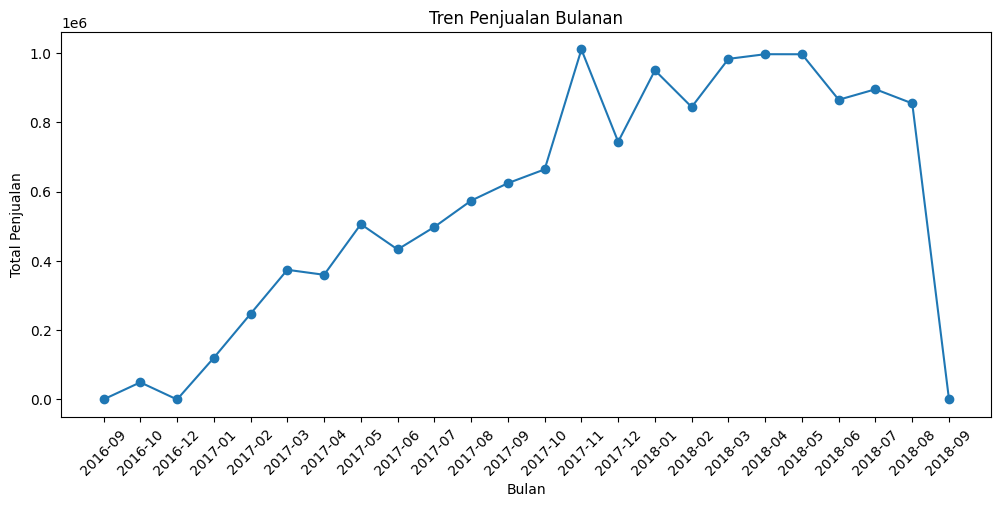

In [ ]:
monthly_sales = df.groupby('Month')['price'].sum()

plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o')

plt.title('Tren Penjualan Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Penjualan')

plt.xticks(rotation=45)

plt.show()

Analisis Produk Terlaris

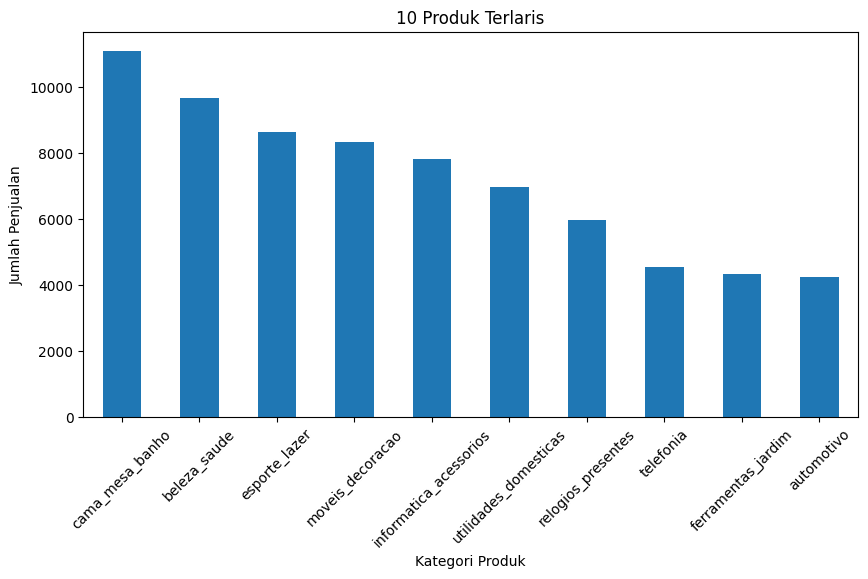

In [ ]:
top_products = df['product_category_name'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_products.plot(kind='bar')

plt.title('10 Produk Terlaris')
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Penjualan')

plt.xticks(rotation=45)

plt.show()

Heatmap Korelasi

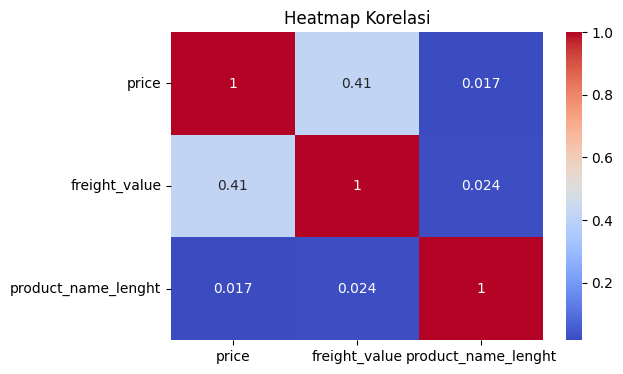

In [ ]:
correlation = df[['price',
                  'freight_value',
                  'product_name_lenght']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title('Heatmap Korelasi')

plt.show()

Kesimpulan Analisis

In [ ]:
print("KESIMPULAN ANALISIS")
print("- Penjualan mengalami perubahan setiap bulan")
print("- Beberapa kategori produk memiliki penjualan tertinggi")
print("- Harga dan biaya pengiriman memiliki hubungan tertentu")

KESIMPULAN ANALISIS
- Penjualan mengalami perubahan setiap bulan
- Beberapa kategori produk memiliki penjualan tertinggi
- Harga dan biaya pengiriman memiliki hubungan tertentu


Identifikasi Produk Underperformer

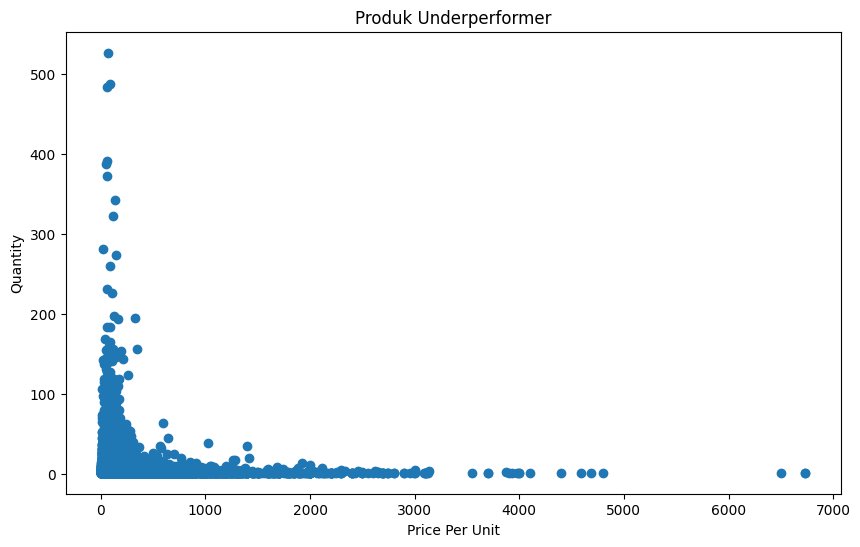

In [ ]:
product_analysis = df.groupby('product_id').agg({
    'price': 'mean',
    'order_item_id': 'count'
}).reset_index()

product_analysis.columns = ['product_id',
                            'Price_Per_Unit',
                            'Quantity']

plt.figure(figsize=(10,6))

plt.scatter(product_analysis['Price_Per_Unit'],
            product_analysis['Quantity'])

plt.title('Produk Underperformer')
plt.xlabel('Price Per Unit')
plt.ylabel('Quantity')

plt.show()

RFM Analysis

In [ ]:
import datetime as dt

snapshot_date = df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'price': 'sum'
})

rfm.columns = ['Recency',
               'Frequency',
               'Monetary']

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,293,1,89.80
000161a058600d5901f007fab4c27140,414,1,54.90
0001fd6190edaaf884bcaf3d49edf079,552,1,179.99
0002414f95344307404f0ace7a26f1d5,383,1,149.90
000379cdec625522490c315e70c7a9fb,154,1,93.00


Pemberian Skor RFM

In [ ]:
rfm['R_Score'] = pd.qcut(rfm['Recency'],
                         5,
                         labels=[5,4,3,2,1])

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                         5,
                         labels=[1,2,3,4,5])

rfm['M_Score'] = pd.qcut(rfm['Monetary'],
                         5,
                         labels=[1,2,3,4,5])

rfm['RFM_Group'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Group
customer_id,,,,,,,
00012a2ce6f8dcda20d059ce98491703,293,1,89.80,2,1,3,213
000161a058600d5901f007fab4c27140,414,1,54.90,1,1,2,112
0001fd6190edaaf884bcaf3d49edf079,552,1,179.99,1,1,5,115
0002414f95344307404f0ace7a26f1d5,383,1,149.90,2,1,4,214
000379cdec625522490c315e70c7a9fb,154,1,93.00,4,1,3,413


Visualisasi Segmentasi Pelanggan

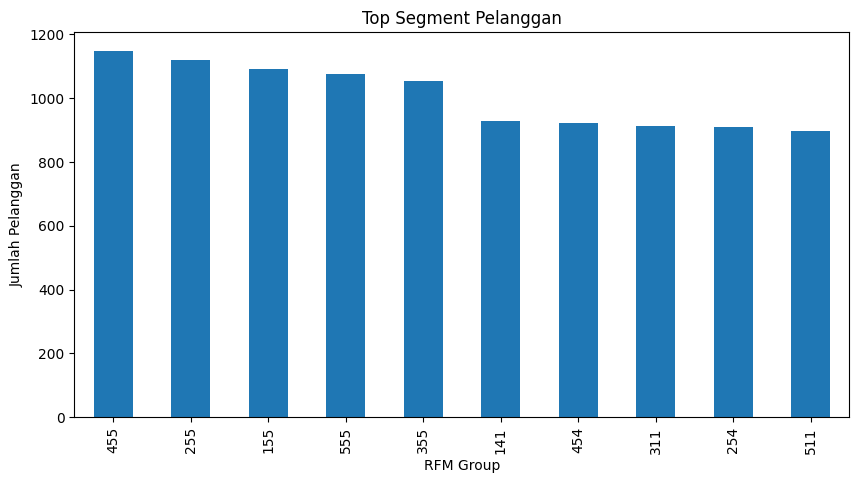

In [ ]:
rfm_segment = rfm['RFM_Group'].value_counts().head(10)

plt.figure(figsize=(10,5))

rfm_segment.plot(kind='bar')

plt.title('Top Segment Pelanggan')
plt.xlabel('RFM Group')
plt.ylabel('Jumlah Pelanggan')

plt.show()

Analisis Kontribusi Kategori

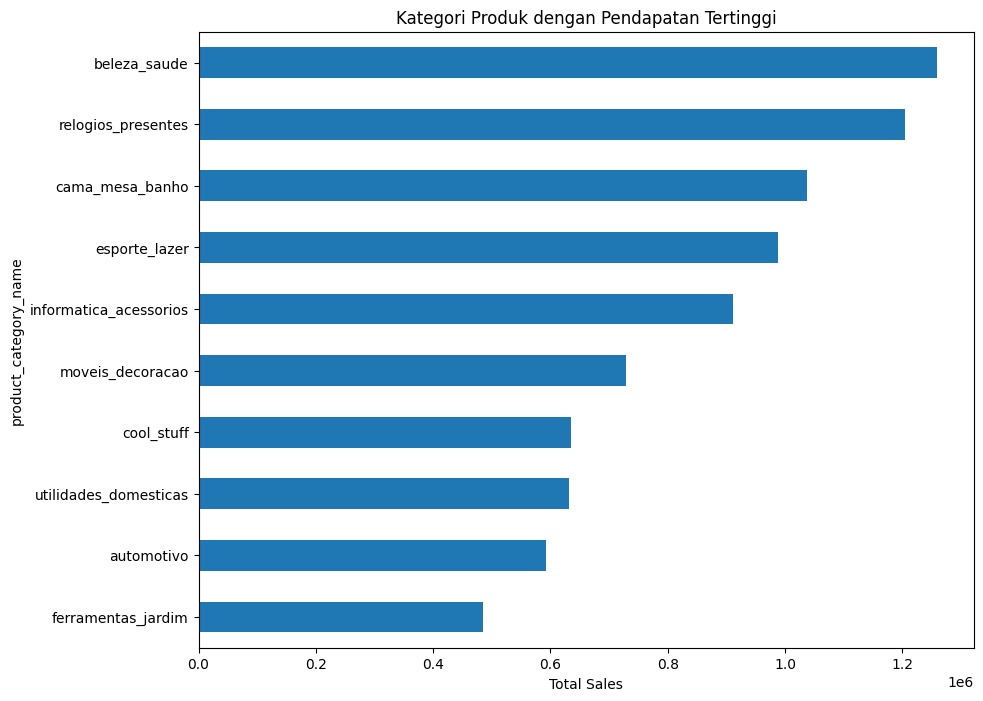

In [ ]:
category_sales = df.groupby('product_category_name')['price'].sum().sort_values()

plt.figure(figsize=(10,8))

category_sales.tail(10).plot(kind='barh')

plt.title('Kategori Produk dengan Pendapatan Tertinggi')
plt.xlabel('Total Sales')

plt.show()

Uji Hipotesis Sederhana

In [ ]:
median_price = df['price'].median()

high_price = df[df['price'] > median_price]['price']
low_price = df[df['price'] <= median_price]['price']

print("Rata-rata Penjualan Harga Tinggi:",
      high_price.mean())

print("Rata-rata Penjualan Harga Rendah:",
      low_price.mean())

Rata-rata Penjualan Harga Tinggi: 200.81081108007615
Rata-rata Penjualan Harga Rendah: 40.82615155649262
